In [1]:
%load_ext autoreload
import os; os.chdir("..")

In [2]:
import matplotlib.pyplot as plt
from permacache import stable_hash

from orthogonal_dfa.analysis.nonlinear_motif_miner import (
    ScoreOracle,
    marginal_records_until,
)
from orthogonal_dfa.analysis.nonlinear_motif_miner_plot import plot_top_motifs
from orthogonal_dfa.data.exon import default_exon
from orthogonal_dfa.l_star.examples.gate_composition_residual import (
    fit_gate_composition_residual,
)
from orthogonal_dfa.l_star.examples.spliceai_oracle import flanks, run_over_middles
from orthogonal_dfa.spliceai.exon_score import SpliceAIExonScore, device_of
from orthogonal_dfa.spliceai.load_model import load_spliceai

### The oracle

SpliceAI's exon score minus a per-length-bin monotonic-gate bag-of-k-mers prediction, so
composition is removed but positional structure is not. The miner itself knows none of
this — it just gets a callable from sequences of symbol indices to scores.

In [3]:
class GateResidualExonScore(ScoreOracle):
    """SpliceAI's exon score minus a per-length-bin monotonic-gate bag-of-k-mers
    prediction, so composition is removed but positional structure is not."""

    alphabet = "ACGT"

    def __init__(self, exon, spliceai_model, *, device=None, chunk=1024, **fit_kw):
        self.exon = exon
        self.chunk = chunk
        self.fit_kw = fit_kw
        self.score_model = SpliceAIExonScore(spliceai_model).eval()
        self.residual = fit_gate_composition_residual(
            self.score_model, exon, device=device, **fit_kw
        )
        self.device = device_of(self.score_model, device)
        self.flank_l, self.flank_r = flanks(exon)

    @property
    def length(self):
        return self.exon.random_text_length

    def scores(self, seqs):
        return run_over_middles(
            self.residual,
            self.flank_l,
            self.flank_r,
            seqs,
            device=self.device,
            chunk=self.chunk,
        )

    def hash_payload(self):
        return [
            stable_hash(self.score_model, version=2),
            stable_hash(self.exon),
            stable_hash(self.fit_kw),
        ]

In [4]:
oracle = GateResidualExonScore(default_exon, load_spliceai(400, 0))

### Marginal-benefit ranking, lengths 1–4 (adaptive)
Same adaptive marginal scan, capped at 4-mers.

In [5]:
records4, info4 = marginal_records_until(
    oracle, 4, 0.04, contexts_per_round=200, max_contexts=16000
)

round 0  n_contexts=200  bound=0.1585
round 1  n_contexts=400  bound=0.1088
round 2  n_contexts=600  bound=0.0868
round 3  n_contexts=800  bound=0.0755
round 4  n_contexts=1000  bound=0.0665
round 5  n_contexts=1200  bound=0.0612
round 6  n_contexts=1400  bound=0.0570
round 7  n_contexts=1600  bound=0.0535
round 8  n_contexts=1800  bound=0.0506
round 9  n_contexts=2000  bound=0.0480
round 10  n_contexts=2200  bound=0.0468
round 11  n_contexts=2400  bound=0.0446
round 12  n_contexts=2600  bound=0.0424
round 13  n_contexts=2800  bound=0.0408
round 14  n_contexts=3000  bound=0.0400
round 15  n_contexts=3200  bound=0.0386


In [6]:
print(info4["n_contexts"], "contexts; achieved bound:", round(info4["bound"], 3))

3200 contexts; achieved bound: 0.039


In [7]:
for r in records4[:30]:
    print(r)

TAG [k=3]  marginal=0.2756
GGTA [k=4]  marginal=0.2755
TGA [k=3]  marginal=0.2608
TAA [k=3]  marginal=0.2583
AGGT [k=4]  marginal=0.2467
GTAA [k=4]  marginal=0.2329
TAAG [k=4]  marginal=0.2113
TAGG [k=4]  marginal=0.2072
TA [k=2]  marginal=0.2052
GGT [k=3]  marginal=0.2002
AG [k=2]  marginal=0.1976
AGTA [k=4]  marginal=0.1970
AGG [k=3]  marginal=0.1948
GTAT [k=4]  marginal=0.1923
GTA [k=3]  marginal=0.1914
AAGT [k=4]  marginal=0.1899
AAGG [k=4]  marginal=0.1896
CGGT [k=4]  marginal=0.1893
AAG [k=3]  marginal=0.1871
GATA [k=4]  marginal=0.1852
GATT [k=4]  marginal=0.1841
AGGA [k=4]  marginal=0.1834
TGAG [k=4]  marginal=0.1825
AGGG [k=4]  marginal=0.1809
GTAC [k=4]  marginal=0.1809
GGTT [k=4]  marginal=0.1808
GAAG [k=4]  marginal=0.1795
GGGT [k=4]  marginal=0.1784
T [k=1]  marginal=0.1780
GAGG [k=4]  marginal=0.1777


<Axes: xlabel='marginal effect'>

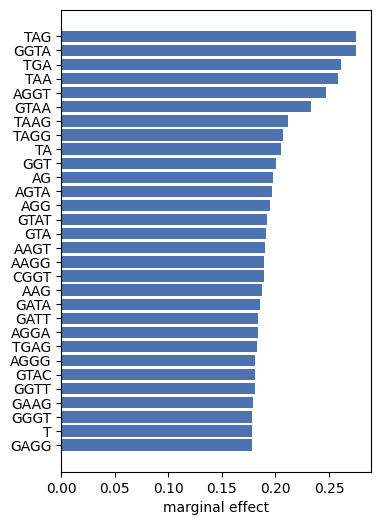

In [8]:
plt.figure(figsize=(4, 6))
plot_top_motifs(records4, top=30)

### Marginal-benefit ranking, lengths 1–6 (adaptive)
Rank every k-mer (k=1..6) by *marginal benefit* — the effect not explained by its best contained (k-1)-mer. Sampling is adaptive: it keeps drawing fresh contexts until the winner's-curse bound on every length's top marginal is below `target_error`, so the 6-mer ranking is trustworthy, not noise. `info` reports the contexts used and the bound achieved.

In [9]:
records, info = marginal_records_until(
    oracle, 6, 0.04, contexts_per_round=200, max_contexts=16000
)

round 0  n_contexts=200  bound=0.2981
round 1  n_contexts=400  bound=0.2071
round 2  n_contexts=600  bound=0.1731
round 3  n_contexts=800  bound=0.1459
round 4  n_contexts=1000  bound=0.1253
round 5  n_contexts=1200  bound=0.1136
round 6  n_contexts=1400  bound=0.1031
round 7  n_contexts=1600  bound=0.0959
round 8  n_contexts=1800  bound=0.0907
round 9  n_contexts=2000  bound=0.0852
round 10  n_contexts=2200  bound=0.0806
round 11  n_contexts=2400  bound=0.0760
round 12  n_contexts=2600  bound=0.0728
round 13  n_contexts=2800  bound=0.0696
round 14  n_contexts=3000  bound=0.0670
round 15  n_contexts=3200  bound=0.0644
round 16  n_contexts=3400  bound=0.0628
round 17  n_contexts=3600  bound=0.0611
round 18  n_contexts=3800  bound=0.0596
round 19  n_contexts=4000  bound=0.0583
round 20  n_contexts=4200  bound=0.0572
round 21  n_contexts=4400  bound=0.0559
round 22  n_contexts=4600  bound=0.0548
round 23  n_contexts=4800  bound=0.0535
round 24  n_contexts=5000  bound=0.0525
round 25  n_co

In [10]:
print(info["n_contexts"], "contexts; achieved bound:", round(info["bound"], 3))

8400 contexts; achieved bound: 0.04


In [11]:
for r in records[:30]:
    print(r)

GGTAAG [k=6]  marginal=0.5017
GTAAGT [k=6]  marginal=0.3994
AGGTA [k=5]  marginal=0.3588
GTAAG [k=5]  marginal=0.3529
GGTAGG [k=6]  marginal=0.3512
AGGTAA [k=6]  marginal=0.3412
GGTGAG [k=6]  marginal=0.3411
GTGAGT [k=6]  marginal=0.3345
TAGGTA [k=6]  marginal=0.3214
GGTAA [k=5]  marginal=0.3082
GGTACG [k=6]  marginal=0.2865
GTAGGT [k=6]  marginal=0.2833
AGGTAG [k=6]  marginal=0.2819
GGTATG [k=6]  marginal=0.2818
AGGTGA [k=6]  marginal=0.2800
TAG [k=3]  marginal=0.2772
GGTA [k=4]  marginal=0.2744
GAATAC [k=6]  marginal=0.2639
GAATAT [k=6]  marginal=0.2616
TGA [k=3]  marginal=0.2611
TAA [k=3]  marginal=0.2565
GTGAG [k=5]  marginal=0.2561
TAAGGT [k=6]  marginal=0.2553
GGTGGG [k=6]  marginal=0.2526
AGGT [k=4]  marginal=0.2494
TAGTAG [k=6]  marginal=0.2461
TAGGT [k=5]  marginal=0.2453
TGAGTA [k=6]  marginal=0.2450
CGATAC [k=6]  marginal=0.2442
GAGGTA [k=6]  marginal=0.2442


<Axes: xlabel='marginal effect'>

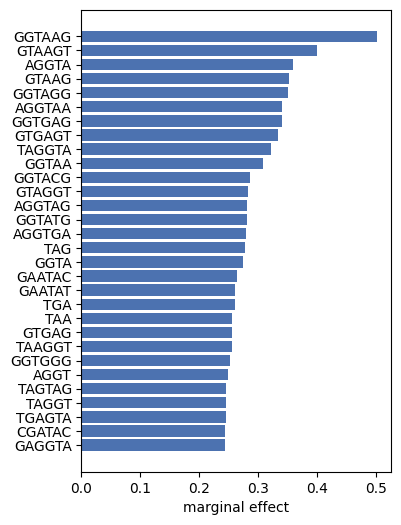

In [12]:
plt.figure(figsize=(4, 6))
plot_top_motifs(records, top=30)